<a href="https://colab.research.google.com/github/it25102877/IT2011-AIML-Project/blob/main/MLP_(ANN)_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# IT2011 - Progress Review II
# Student: Fernando B. K. H. (IT25102631)
# Model: Multi-Layer Perceptron (ANN) - Deep Learning
# Based on Lab Sheet 07 & Lab Sheet 08
# ============================================================

# -------------------- CELL 1: Imports --------------------
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# -------------------- CELL 2: Load Dataset --------------------
from google.colab import drive
drive.mount('/content/drive')

# Change this path if your file is in a different location
DATA_PATH = "/content/drive/MyDrive/final_preprocessed_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Mounted at /content/drive
Dataset shape: (46173, 79)

Columns: ['movie_name', 'Ratings', 'Ratings_scaled', 'emotion', 'emotion_label', 'cleaned_review', 'lemmatized_review', 'word_count_scaled', 'char_count_scaled', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western', 'LSA_1', 'LSA_2', 'LSA_3', 'LSA_4', 'LSA_5', 'LSA_6', 'LSA_7', 'LSA_8', 'LSA_9', 'LSA_10', 'LSA_11', 'LSA_12', 'LSA_13', 'LSA_14', 'LSA_15', 'LSA_16', 'LSA_17', 'LSA_18', 'LSA_19', 'LSA_20', 'LSA_21', 'LSA_22', 'LSA_23', 'LSA_24', 'LSA_25', 'LSA_26', 'LSA_27', 'LSA_28', 'LSA_29', 'LSA_30', 'LSA_31', 'LSA_32', 'LSA_33', 'LSA_34', 'LSA_35', 'LSA_36', 'LSA_37', 'LSA_38', 'LSA_39', 'LSA_40', 'LSA_41', 'LSA_42', 'LSA_43', 'LSA_44', 'LSA_45',

,movie_name,Ratings,Ratings_scaled,emotion,emotion_label,cleaned_review,lemmatized_review,word_count_scaled,char_count_scaled,genre_Action,...,LSA_41,LSA_42,LSA_43,LSA_44,LSA_45,LSA_46,LSA_47,LSA_48,LSA_49,LSA_50
0,Waiting to Exhale,3.0,0.222222,anticipation,1,it had some laughs but overall the motivation ...,laugh overall motivation character incomprehen...,-0.762821,-0.720442,0,...,0.036990,-0.054270,0.020441,0.048175,0.018404,-0.007786,0.003789,-0.011600,-0.021951,0.036462
1,Waiting to Exhale,4.0,0.333333,anticipation,1,waiting to exhale waiting and waiting and wait...,waiting exhale waiting waiting waiting waiting...,1.173077,1.308287,0,...,0.025372,0.001595,-0.012987,0.029608,-0.006854,0.009810,-0.021013,0.007206,0.010680,0.004767
2,Waiting to Exhale,4.0,0.333333,anticipation,1,angela basset was good as expected but whitney...,angela basset good expected whitney range scre...,-0.839744,-0.773481,0,...,0.027154,-0.034242,0.050720,0.126149,0.041413,0.007349,-0.076408,0.077268,-0.022318,0.013545


In [3]:
# -------------------- CELL 3: Prepare Features & Target --------------------
feature_cols = (
    ['Ratings_scaled', 'word_count_scaled', 'char_count_scaled'] +
    [c for c in df.columns if c.startswith('genre_')] +
    [c for c in df.columns if c.startswith('LSA_')]
)

X = df[feature_cols].values
y = df['emotion_label'].values

print("Feature matrix shape:", X.shape)
print("Number of classes:", len(np.unique(y)))
print("\nClass distribution:")
print(pd.Series(y).value_counts().sort_index())

Feature matrix shape: (46173, 73)
Number of classes: 8

Class distribution:
0     3638
1     7336
2     1670
3     3460
4     7861
5     4812
6    17339
7       57
Name: count, dtype: int64


In [4]:
# -------------------- CELL 4: Train-Test Split + One-Hot Encoding --------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# One-hot encode the target (required for categorical_crossentropy)
y_train_cat = to_categorical(y_train)
y_test_cat  = to_categorical(y_test)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("y_train_cat shape:", y_train_cat.shape)

Training samples: 36938
Testing samples : 9235
y_train_cat shape: (36938, 8)


In [5]:
# -------------------- CELL 5: Feature Scaling --------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


In [6]:
# -------------------- CELL 6: Build Baseline MLP Model --------------------
num_features = X_train_scaled.shape[1]
num_classes  = y_train_cat.shape[1]

baseline_model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation='relu'),          # Hidden Layer 1
    layers.Dense(32, activation='relu'),          # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline Model Summary:")
baseline_model.summary()

Baseline Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,080 (27.66 KB)

 Trainable params: 7,080 (27.66 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# -------------------- CELL 7: Train Baseline Model --------------------
history_baseline = baseline_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3770 - loss: 1.6728 - val_accuracy: 0.3904 - val_loss: 1.6005
Epoch 2/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4042 - loss: 1.5682 - val_accuracy: 0.3994 - val_loss: 1.5664
Epoch 3/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4141 - loss: 1.5255 - val_accuracy: 0.4086 - val_loss: 1.5374
Epoch 4/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4262 - loss: 1.4921 - val_accuracy: 0.4164 - val_loss: 1.5279
Epoch 5/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4348 - loss: 1.4650 - val_accuracy: 0.4192 - val_loss: 1.5147
Epoch 6/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4423 - loss: 1.4422 - val_accuracy: 0.4258 - val_loss: 1.5030
Epoch 7/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4490 - loss: 1.4214 - val_accuracy: 0.4274 - val_loss: 1.4911
Epoch 8/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4538 - loss: 1.4052 - val_accuracy: 0.

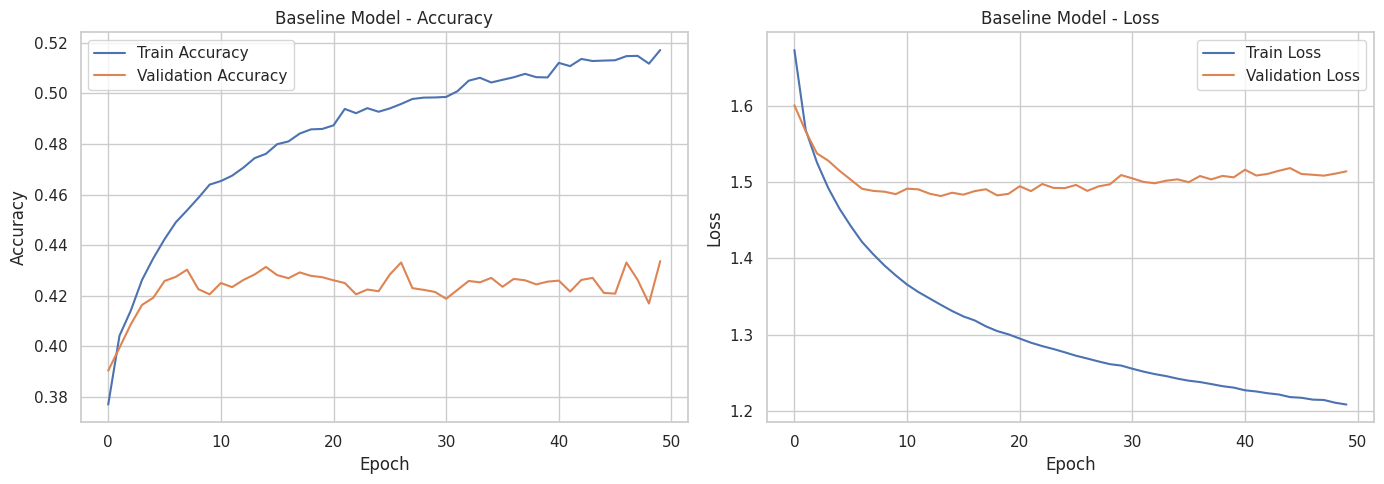

In [8]:
# -------------------- CELL 8: Plot Training Curves (Baseline) --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history_baseline.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Baseline Model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history_baseline.history['loss'], label='Train Loss')
axes[1].plot(history_baseline.history['val_loss'], label='Validation Loss')
axes[1].set_title('Baseline Model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_baseline_curves.png', dpi=300)
plt.show()

In [9]:
# -------------------- CELL 9: Evaluate Baseline Model --------------------
test_loss, test_acc = baseline_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("=== Baseline MLP Results ===")
print("Test Accuracy:", round(test_acc, 4))

y_pred_baseline = np.argmax(baseline_model.predict(X_test_scaled), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

print("F1-Score (Weighted):", round(f1_score(y_test, y_pred_baseline, average='weighted'), 4))

=== Baseline MLP Results ===
Test Accuracy: 0.4191
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.22      0.28       728
           1       0.32      0.20      0.25      1467
           2       0.27      0.14      0.18       334
           3       0.37      0.27      0.31       692
           4       0.39      0.20      0.27      1572
           5       0.37      0.27      0.31       963
           6       0.46      0.75      0.57      3468
           7       0.40      0.18      0.25        11

    accuracy                           0.42      9235
   macro avg       0.37      0.28      0.30      9235
weighted avg       0.39      0.42      0.38      9235

F1-Score (Weighted): 0.3822


In [10]:
# -------------------- CELL 10: Improved MLP Model (Dropout + EarlyStopping) --------------------
improved_model = keras.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Improved Model Summary:")
improved_model.summary()

Improved Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,072 (78.41 KB)

 Trainable params: 20,072 (78.41 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# -------------------- CELL 11: Train Improved Model --------------------
history_improved = improved_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3701 - loss: 1.7064 - val_accuracy: 0.3872 - val_loss: 1.6120
Epoch 2/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3845 - loss: 1.6229 - val_accuracy: 0.3912 - val_loss: 1.5702
Epoch 3/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3894 - loss: 1.5924 - val_accuracy: 0.3983 - val_loss: 1.5533
Epoch 4/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3933 - loss: 1.5694 - val_accuracy: 0.4013 - val_loss: 1.5374
Epoch 5/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3947 - loss: 1.5539 - val_accuracy: 0.4067 - val_loss: 1.5209
Epoch 6/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4010 - loss: 1.5374 - val_accuracy: 0.4100 - val_loss: 1.5039
Epoch 7/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4075 - loss: 1.5229 - val_accuracy: 0.4168 - val_loss: 1.4884
Epoch 8/50
924/924 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4104 - loss: 1.5074 - val_accuracy: 0.

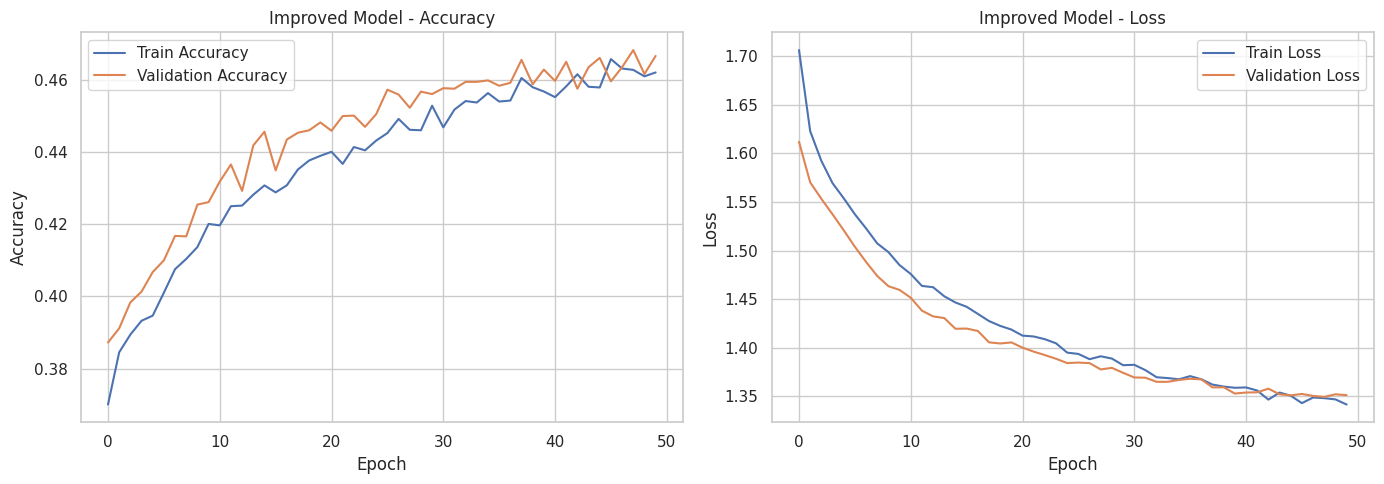

In [12]:
# -------------------- CELL 12: Plot Training Curves (Improved) --------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_improved.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Improved Model - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_improved.history['loss'], label='Train Loss')
axes[1].plot(history_improved.history['val_loss'], label='Validation Loss')
axes[1].set_title('Improved Model - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_improved_curves.png', dpi=300)
plt.show()

In [13]:
# -------------------- CELL 13: Evaluate Improved Model --------------------
test_loss2, test_acc2 = improved_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print("=== Improved MLP Results ===")
print("Test Accuracy:", round(test_acc2, 4))

y_pred_improved = np.argmax(improved_model.predict(X_test_scaled), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_improved))

print("F1-Score (Weighted):", round(f1_score(y_test, y_pred_improved, average='weighted'), 4))

=== Improved MLP Results ===
Test Accuracy: 0.454
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.23      0.31       728
           1       0.39      0.19      0.26      1467
           2       0.38      0.26      0.31       334
           3       0.39      0.28      0.33       692
           4       0.49      0.22      0.30      1572
           5       0.57      0.18      0.27       963
           6       0.46      0.85      0.59      3468
           7       1.00      0.09      0.17        11

    accuracy                           0.45      9235
   macro avg       0.52      0.29      0.32      9235
weighted avg       0.46      0.45      0.40      9235

F1-Score (Weighted): 0.4041


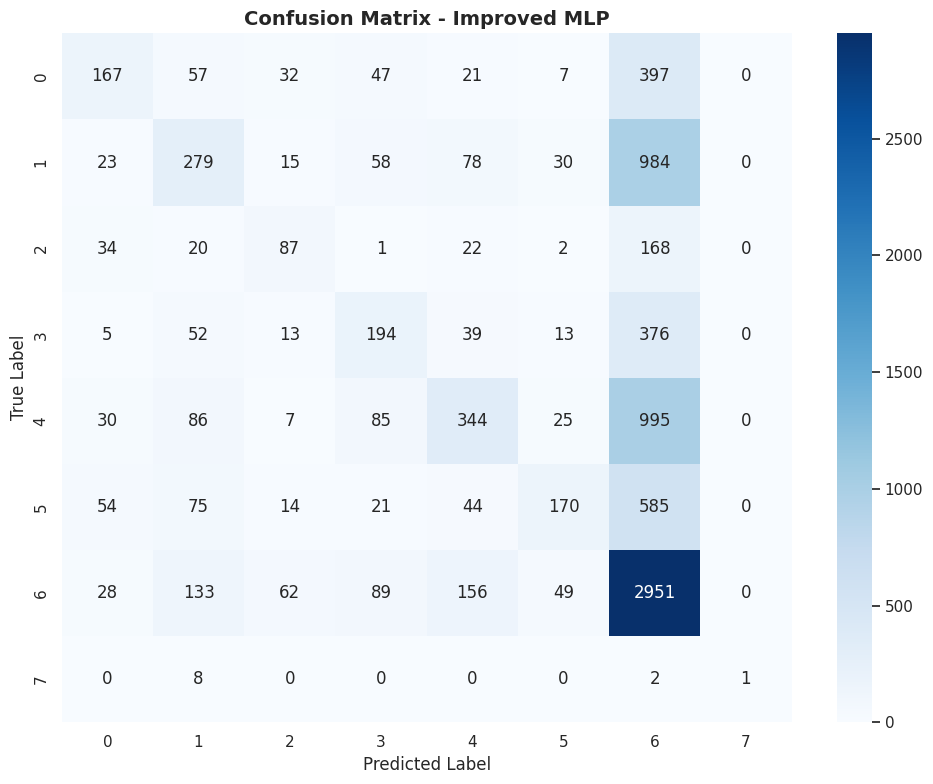

In [14]:
# -------------------- CELL 14: Confusion Matrix --------------------
cm = confusion_matrix(y_test, y_pred_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Improved MLP", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig('mlp_confusion_matrix.png', dpi=300)
plt.show()

In [15]:
# -------------------- CELL 15: Comparison of Model Varieties --------------------
comparison = pd.DataFrame({
    "Model Variety": ["Baseline MLP", "Improved MLP (Dropout + EarlyStopping)"],
    "Test Accuracy": [round(test_acc, 4), round(test_acc2, 4)],
    "F1-Score (Weighted)": [
        round(f1_score(y_test, y_pred_baseline, average='weighted'), 4),
        round(f1_score(y_test, y_pred_improved, average='weighted'), 4)
    ]
})

print(comparison)

                            Model Variety  Test Accuracy  F1-Score (Weighted)
0                            Baseline MLP         0.4191               0.3822
1  Improved MLP (Dropout + EarlyStopping)         0.4540               0.4041


In [16]:
# -------------------- CELL 16: Final Summary for Viva --------------------
print("""
============================================================
MLP (ANN) MODEL - SUMMARY
Student: Fernando B. K. H. (IT25102631)
============================================================

1. Model Suitability:
   - Task: Multi-class emotion classification (8 classes)
   - MLP is suitable because all features are numerical
     (scaled ratings + genre binary features + LSA components)

2. Implementation:
   - Library: TensorFlow / Keras
   - Architecture: Dense layers with ReLU + Softmax output
   - Loss: categorical_crossentropy
   - Optimizer: Adam

3. Hyperparameter Tuning / Varieties:
   - Baseline: 64 → 32 → 8 (softmax)
   - Improved: 128 → Dropout(0.3) → 64 → Dropout(0.3) → 32 → 8
   - Used EarlyStopping (patience=5)

4. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)
   - Why weighted F1? → Dataset is imbalanced

5. Validation Method:
   - Stratified Train-Test Split (80/20)
   - validation_split = 0.2 during training

6. Comparison:
   - Improved model generally performs better and reduces overfitting

7. Limitations:
   - Class imbalance still affects rare classes (e.g. surprise)
   - Does not use the sequential nature of original review text

8. Possible Improvements:
   - Add class weights
   - Try different optimizers (RMSprop, SGD)
   - Increase model depth carefully
============================================================
""")


MLP (ANN) MODEL - SUMMARY
Student: Fernando B. K. H. (IT25102631)

1. Model Suitability:
   - Task: Multi-class emotion classification (8 classes)
   - MLP is suitable because all features are numerical
     (scaled ratings + genre binary features + LSA components)

2. Implementation:
   - Library: TensorFlow / Keras
   - Architecture: Dense layers with ReLU + Softmax output
   - Loss: categorical_crossentropy
   - Optimizer: Adam

3. Hyperparameter Tuning / Varieties:
   - Baseline: 64 → 32 → 8 (softmax)
   - Improved: 128 → Dropout(0.3) → 64 → Dropout(0.3) → 32 → 8
   - Used EarlyStopping (patience=5)

4. Evaluation Metrics:
   - Accuracy, Precision, Recall, F1-Score (weighted)
   - Why weighted F1? → Dataset is imbalanced

5. Validation Method:
   - Stratified Train-Test Split (80/20)
   - validation_split = 0.2 during training

6. Comparison:
   - Improved model generally performs better and reduces overfitting

7. Limitations:
   - Class imbalance still affects rare classes (e.g.